# Mall Customer Segmentation using K-Means Clustering

## Project Objective

The objective of this project is to segment mall customers into different groups based on their purchasing behavior.

K-Means Clustering will be used to identify customers with similar characteristics using the following features:

- Annual Income (k$)
- Spending Score (1-100)

The optimal number of clusters will be determined using the Elbow Method, and the clustering quality will be evaluated using the Silhouette Score.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Dataset Overview

In [50]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Missing Values and Duplicate Rows

In [51]:
display(df.isnull().sum())

df.duplicated().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

np.int64(0)

### Statistical Summary

In [52]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Exploratory Data Analysis
### Distribution of Numerical Features

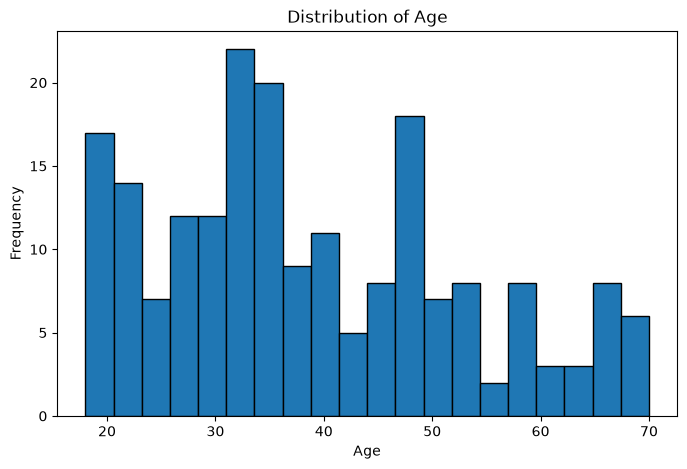

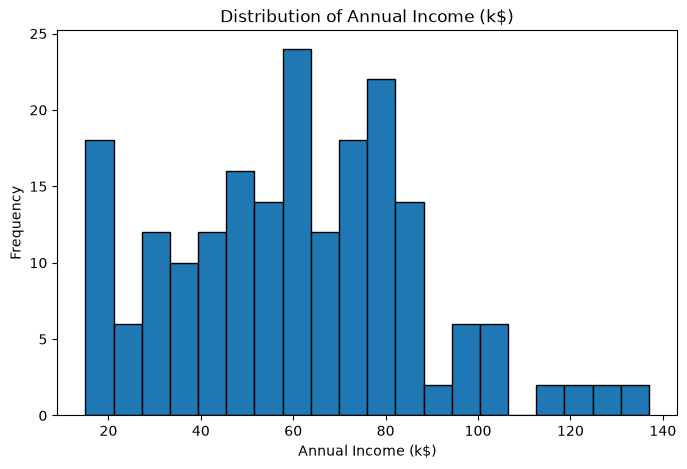

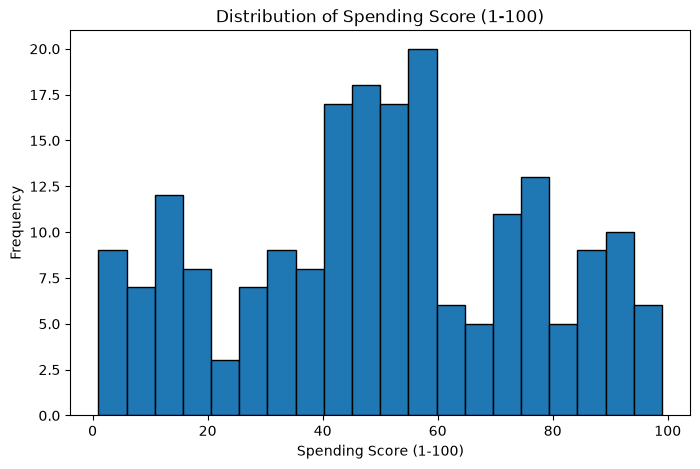

In [53]:
numerical_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

for column in numerical_columns:
    plt.figure(figsize=(8,5))
    plt.hist(
        df[column],
        bins=20,
        edgecolor="black"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")
    plt.savefig(f"../images/Distribution_of_{column}.png")
    plt.show()

### Gender Distribution

In [54]:
gender_counts = df["Gender"].value_counts()
print(gender_counts)

Gender
Female    112
Male       88
Name: count, dtype: int64


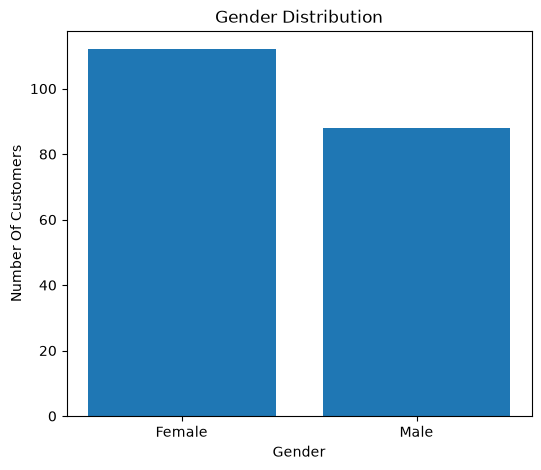

In [55]:
plt.figure(figsize=(6,5))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.xlabel("Gender")
plt.ylabel("Number Of Customers")
plt.title("Gender Distribution")
plt.savefig("../images/Gender_distribution.png")
plt.show()

### Annual Income vs Spending Score

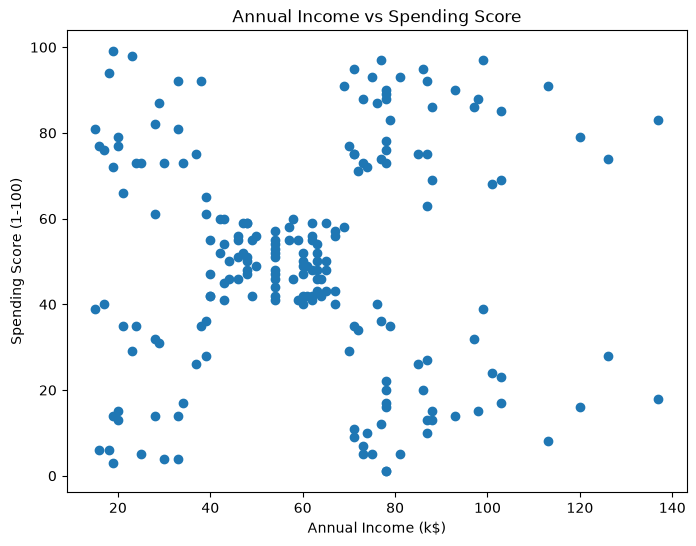

In [56]:
plt.figure(figsize = (8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.savefig("../images/Annual_income_VS_Spending_score.png")
plt.show()

# Feature Selection

In [57]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Feature Scaling

K-Means uses Euclidean distance to calculate the similarity between data points. Therefore, we apply StandardScaler() so both features are placed on the same scale.

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

### Elbow Method

In [59]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)



### Elbow Curve

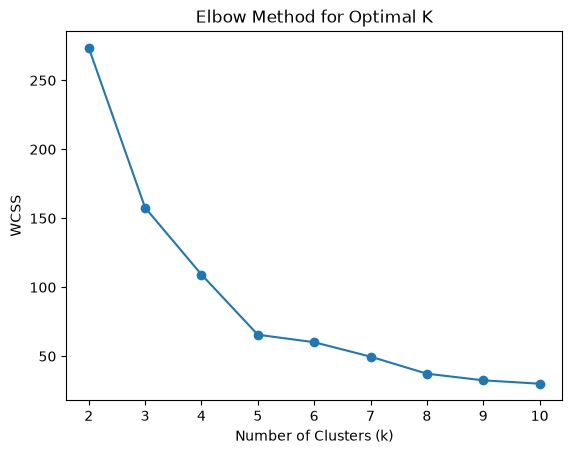

In [60]:
plt.Figure(figsize=(8,6))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.savefig("../images/Elbow_Method.png")
plt.show()

### K-Means Model Building

In [61]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)","[

### Assigning Cluster Labels

In [62]:
df["Clusters"] = kmeans.labels_

df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters
175,176,Female,30,88,86,1
27,28,Male,35,28,61,2
171,172,Male,28,87,75,1
120,121,Male,27,67,56,0
72,73,Female,60,50,49,0


### Customer Segmentation Visualization

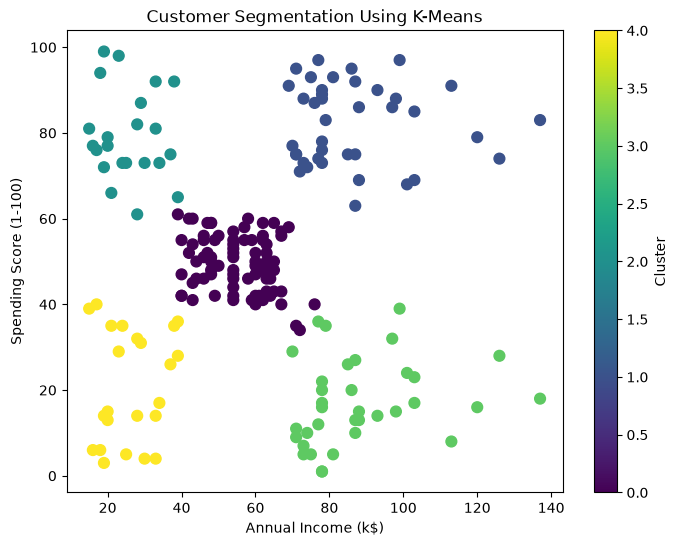

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Clusters"],
    cmap="viridis",
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation Using K-Means")
plt.colorbar(label="Cluster")
plt.savefig("../images/Customer_Segmentation.png")
plt.show()

### Cluster Analysis

In [64]:
cluster_summary = df.groupby("Clusters")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


### Silhouette Score

In [65]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    df["Clusters"]
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.5547


### Cluster Size Analysis

In [66]:
cluster_counts = df["Clusters"].value_counts().sort_index()

cluster_counts

Clusters
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Cluster Size Visualization

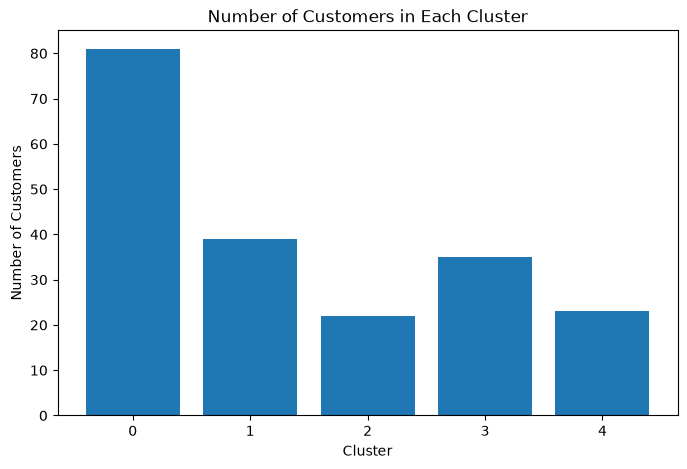

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")
plt.savefig("../images/Num_of_Customers_in_Cluster.png")

plt.show()

### Cluster Centroids

In [68]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        "Annual Income (Scaled)",
        "Spending Score (Scaled)"
    ]
)

centroids

,Annual Income (Scaled),Spending Score (Scaled)
0,-0.200913,-0.026456
1,0.991583,1.239503
2,-1.329545,1.132178
3,1.055003,-1.284439
4,-1.307519,-1.136965


### Cluster Centroids (Original Scale)

In [69]:
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

centroids_original

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


### Cluster-wise Feature Distribution

<Figure size 800x500 with 0 Axes>

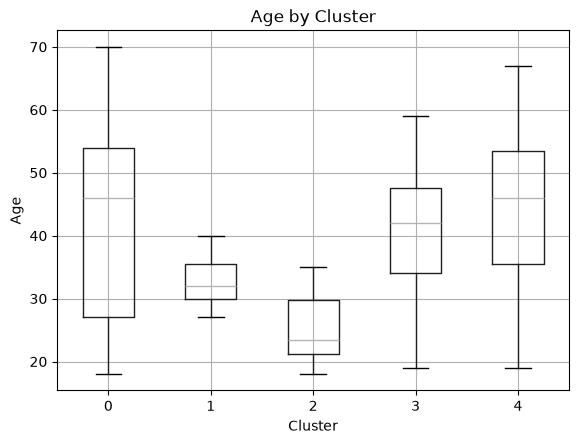

<Figure size 800x500 with 0 Axes>

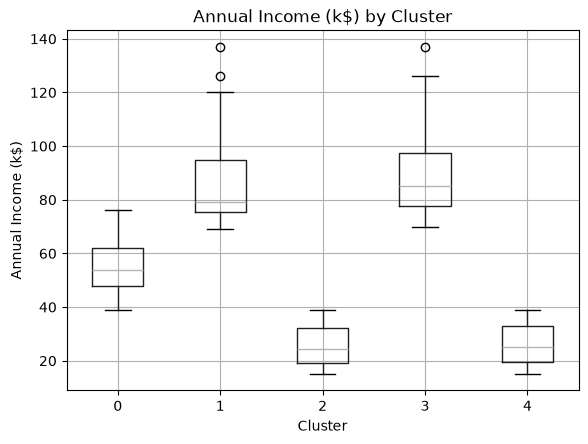

<Figure size 800x500 with 0 Axes>

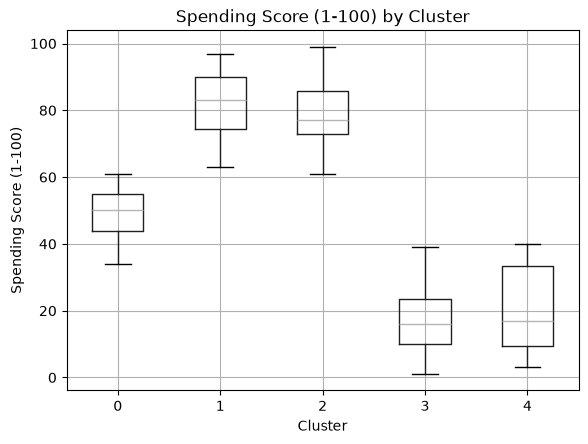

In [70]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

for feature in features:
    plt.figure(figsize=(8, 5))

    df.boxplot(
        column=feature,
        by="Clusters"
    )

    plt.title(f"{feature} by Cluster")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.savefig(f"../images/{feature} by Cluster")
    plt.show()

# Hierarchical Clustering

In [71]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

linked = linkage(
    X_scaled,
    method="ward"
)

### Plot the Dendrogram

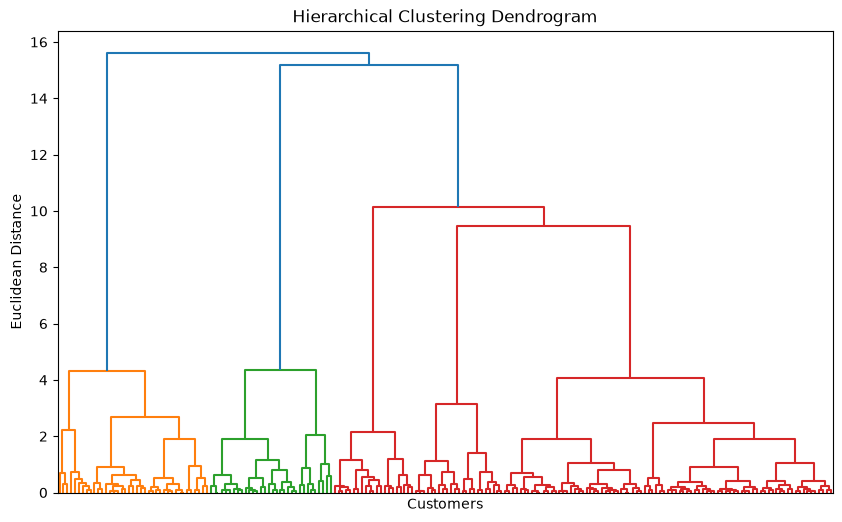

In [72]:
plt.figure(figsize=(10, 6))

dendrogram(linked, no_labels=True)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.savefig("../images/Hierarchical_Dendrogram.png")

plt.show()

### Agglomerative Hierarchical Clustering

In [73]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hierarchical_clusters = hierarchical_model.fit_predict(X_scaled)

hierarchical_clusters[:10]

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3])

### Add Hierarchical Cluster Labels

In [74]:
df["Hierarchical Cluster"] = hierarchical_clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters,Hierarchical Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4


### Hierarchical Clustering Visualization

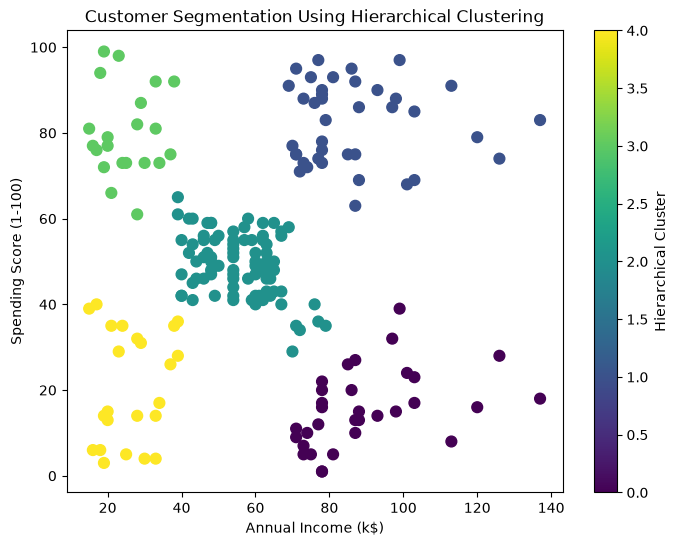

In [75]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Hierarchical Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Customer Segmentation Using Hierarchical Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(label="Hierarchical Cluster")

plt.savefig("../images/Hierarchical_Customer_Segmentation.png")

plt.show()

### Hierarchical Clustering Evaluation

In [76]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    df["Hierarchical Cluster"]
)

print(f"Hierarchical Silhouette Score: {hierarchical_silhouette:.4f}")

Hierarchical Silhouette Score: 0.5538


### Comparison of Clustering Algorithms

In [77]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        silhouette,
        hierarchical_silhouette
    ]
})

comparison

,Algorithm,Silhouette Score
0,K-Means,0.554657
1,Hierarchical Clustering,0.553809


# DBSCAN Clustering

### DBSCAN Model

In [78]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(X_scaled)

dbscan_clusters[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### DBSCAN Cluster Labels

In [79]:
df["DBSCAN Cluster"] = dbscan_clusters
df["DBSCAN Cluster"].value_counts().sort_index()

DBSCAN Cluster
-1      8
 0    157
 1     35
Name: count, dtype: int64

In [80]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters,Hierarchical Cluster,DBSCAN Cluster
0,1,Male,19,15,39,4,4,0
1,2,Male,21,15,81,2,3,0
2,3,Female,20,16,6,4,4,0
3,4,Female,23,16,77,2,3,0
4,5,Female,31,17,40,4,4,0


### DBSCAN Cluster Visualization

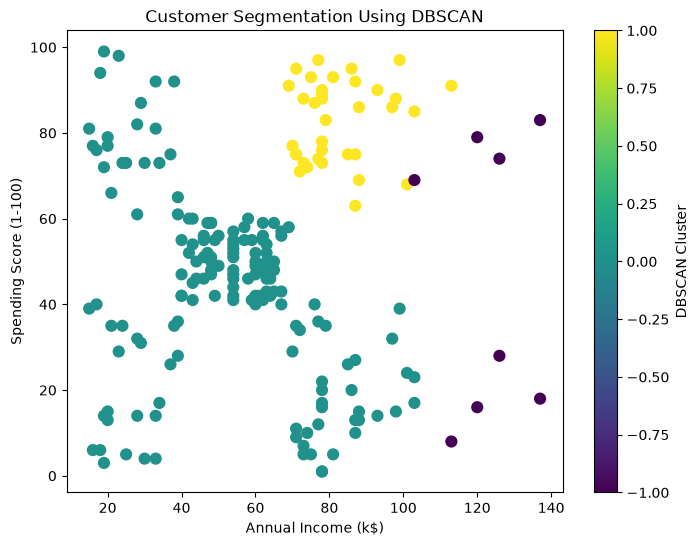

In [81]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["DBSCAN Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Customer Segmentation Using DBSCAN")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(label="DBSCAN Cluster")

plt.savefig("../images/DBSCAN_Customer_Segmentation.png")

plt.show()

### Clustering Algorithm Comparison

In [82]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN"
    ],
    "Number of Clusters": [
        5,
        5,
        2
    ],
    "Noise Points": [
        0,
        0,
        8
    ],
    "Silhouette Score": [
        silhouette,
        hierarchical_silhouette,
        "N/A"
    ]
})

comparison

,Algorithm,Number of Clusters,Noise Points,Silhouette Score
0,K-Means,5,0,0.554657
1,Hierarchical Clustering,5,0,0.553809
2,DBSCAN,2,8,N/A


## Key Findings

- K-Means achieved the highest Silhouette Score (0.5547).
- Hierarchical Clustering produced a very similar clustering structure with a Silhouette Score of 0.5538.
- DBSCAN identified 2 dense clusters and detected 8 noise points without requiring the number of clusters as input.
- For this dataset, K-Means provided the most interpretable customer segmentation.